# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [7]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


## 2. Imports and Reproducibility


In [8]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [9]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 4. Load the Data


In [10]:
def load_har_data(root_dir="UCI HAR Dataset"):
    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt"))
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt")).astype(int) - 1

    X_test = np.loadtxt(os.path.join(root_dir, "test", "X_test.txt"))
    y_test = np.loadtxt(os.path.join(root_dir, "test", "y_test.txt")).astype(int) - 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

num_features = X_train.shape[1]
num_classes = len(np.unique(y_train))

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("Number of input features:", num_features)
print("Number of classes:", num_classes)


X_train shape: (7352, 561)
X_test shape : (2947, 561)
Number of input features: 561
Number of classes: 6


## 5. Quick Inspection


In [11]:
# TODO:
# Create a small summary table showing the class index, class name, and number of training samples.

label_counts = pd.Series(y_train).value_counts().sort_index()

dataset_summary = pd.DataFrame({
    "Class Index": list(range(num_classes)),
    "Class Name": class_names,
    "Training Samples": label_counts.values,
})

dataset_summary



,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [53]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    # <-- Enter your code here <--#
    inputs = keras.Input(shape=(input_dim), name = "features")
    x = layers.Dense (256, activation = "relu")(inputs)
    x = layers.Dense(128, activation = "relu")(x)
    x = layers.Dense(64, activation = "relu")(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name = "baseline_dnn")

    model.compile (optimizer = keras.optimizers.Adam(learning_rate = 1e-3),
                    loss = "sparse_categorical_crossentropy",
                    metrics = ["accuracy"],)
    return model
    

            
    #raise NotImplementedError("Complete the baseline DNN.")

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "baseline_dnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 features (InputLayer)       [(None, 561)]             0         
                                                                 
 dense_7 (Dense)             (None, 256)               143872    
                                                                 
 dense_8 (Dense)             (None, 128)               32896     
                                                                 
 dense_9 (Dense)             (None, 64)                8256      
                                                                 
 dense_10 (Dense)            (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [60]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

# <-- Enter your code here <--#
history_baseline = baseline_model.fit (
    X_train,
    y_train,
    validation_split = .2,
    epochs = 40,
    batch_size = 64,
    callbacks = callbacks,
    verbose = 1
)

baseline_accuracy = baseline_model.evaluate(X_test, y_test, verbose = 0)[1]


Epoch 1/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0451 - accuracy: 0.9806 - val_loss: 0.1221 - val_accuracy: 0.9572
Epoch 2/40
92/92 [==============================] - 0s 914us/step - loss: 0.0591 - accuracy: 0.9760 - val_loss: 0.1316 - val_accuracy: 0.9483
Epoch 3/40
92/92 [==============================] - 0s 894us/step - loss: 0.0407 - accuracy: 0.9850 - val_loss: 0.1196 - val_accuracy: 0.9551
Epoch 4/40
92/92 [==============================] - 0s 865us/step - loss: 0.0450 - accuracy: 0.9821 - val_loss: 0.1171 - val_accuracy: 0.9592
Epoch 5/40
92/92 [==============================] - 0s 886us/step - loss: 0.0366 - accuracy: 0.9862 - val_loss: 0.1179 - val_accuracy: 0.9579
Epoch 6/40
92/92 [==============================] - 0s 862us/step - loss: 0.0357 - accuracy: 0.9874 - val_loss: 0.1482 - val_accuracy: 0.9585
Epoch 7/40
92/92 [==============================] - 0s 869us/step - loss: 0.0475 - accuracy: 0.9816 - val_loss: 0.1181 - val_accuracy: 0.9517
Epoch 8/

### Training Curves


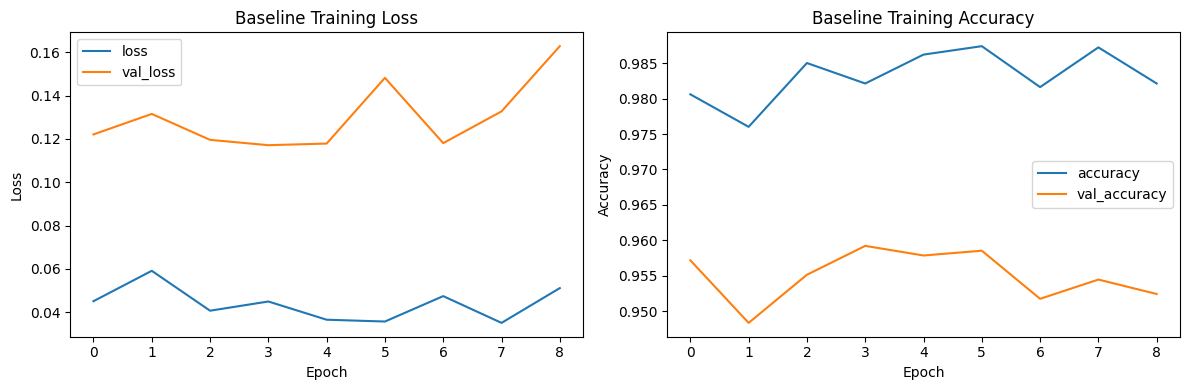

In [61]:
# TODO:
# Plot the training and validation accuracy.
# Plot the training and validation loss.

# <-- Enter your code here <--#
history_baseline_df = pd.DataFrame(history_baseline.history)


fig, axes = plt.subplots(1, 2, figsize = (12,4))
history_baseline_df [["loss", "val_loss"]].plot(ax = axes[0], title="Baseline Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")


history_baseline_df[["accuracy", "val_accuracy"]].plot(ax=axes[1], title="Baseline Training Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")


plt.tight_layout()
plt.show()


## 7. Evaluate the Baseline Keras Model


93/93 [==============================] - 0s 414us/step
Test Accuracy :  0.9419748897183576
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       496
           1       0.92      0.93      0.93       471
           2       0.98      0.91      0.94       420
           3       0.95      0.86      0.91       491
           4       0.88      0.96      0.92       532
           5       1.00      0.99      0.99       537

    accuracy                           0.94      2947
   macro avg       0.94      0.94      0.94      2947
weighted avg       0.94      0.94      0.94      2947



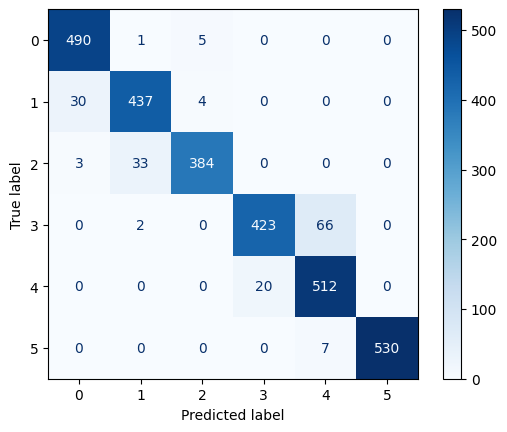

In [62]:
# TODO:
# 1. Obtain predicted probabilities on X_test
# 2. Convert them to class predictions using argmax
# 3. Compute test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix
y_pred_prob = baseline_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print("Test Accuracy : ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,cmap="Blues")
plt.show()


## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [107]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    # TODO:
    # Yield 300 representative samples from X_train as float32 tensors.
    # Each yielded item should be in the form: [sample]
    for i in range(300):
        sample = X_train[i:i+1].astype(np.float32)
        yield [sample]

    # <-- Enter your code here <--#
    
def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)
        if input_details["dtype"] == np.int8:
            x = np.round(x/input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round (x / input_scale + input_zero_point).astype(np.uint8)
        else: 
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        
            

        # TODO:
        # Quantize the input only when the input dtype is int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        # <-- Enter your code here <--#

        if((output_details["dtype"]) == np.int8 or (output_details["dtype"])== np.uint8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        # TODO:
        # If the output is quantized, dequantize it back to float32.

        # <-- Enter your code here <--#

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()
    # TODO: return the converted FP32 TensorFlow Lite model
    # <-- Enter your code here <--#

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization and return the converted model.
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    return converter.convert()
    # <-- Enter your code here <--#

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Set supported_types to [tf.float16]
    # Return the converted model

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()
    

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Attach representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    # Set inference_input_type and inference_output_type to tf.int8
    # Return the converted model

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    return converter.convert()


## 9. Post-Training Quantization (PTQ)


In [108]:
# TODO:
# Convert the baseline model into:
# - FP32 TFLite
# - dynamic range TFLite
# - float16 TFLite
# - int8 TFLite

# Save each model to disk and record its size in KB.
# Evaluate each TFLite model on the test set.

# <-- Enter your code here <--#
fp32_tflite = convert_to_tflite_fp32(baseline_model)
fp32_size = save_binary_model(fp32_tflite, "baseline_fp32.tflite")
fp32_acc, _ = evaluate_tflite_model(fp32_tflite, X_test, y_test)


dynamic_tflite = convert_to_tflite_dynamic_range(baseline_model)
dynamic_size = save_binary_model(dynamic_tflite, "baseline_dynamic_range.tflite")
dyn_acc, _ = evaluate_tflite_model(dynamic_tflite, X_test, y_test)


int8_tflite = convert_to_tflite_int8(baseline_model)
int8_size = save_binary_model(int8_tflite, "baseline_int8.tflite")
int8_acc, int8_pred = evaluate_tflite_model(int8_tflite,X_test, y_test)



float16_tflite = convert_to_tflite_float16(baseline_model)
float16_size = save_binary_model(float16_tflite, "baseline_float16.tflite")
float16_acc, _ = evaluate_tflite_model(float16_tflite, X_test, y_test)


print ("Saved baseline_fp32.tflite")
print ("Saved baseline_dynamic_range.tflite")
print ("Saved baseline_float16.tflite")
print ("Saved baseline_int8.tflite")



INFO:tensorflow:Assets written to: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmpudiz9sgy/assets


INFO:tensorflow:Assets written to: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmpudiz9sgy/assets
2026-04-22 17:12:02.470154: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 17:12:02.470322: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 17:12:02.471709: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmpudiz9sgy
2026-04-22 17:12:02.472132: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 17:12:02.472136: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmpudiz9sgy
2026-04-22 17:12:02.477675: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-22 17:12:02.529948: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmprzfgb2dj/assets


INFO:tensorflow:Assets written to: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmprzfgb2dj/assets
2026-04-22 17:12:02.819662: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 17:12:02.819671: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 17:12:02.819741: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmprzfgb2dj
2026-04-22 17:12:02.820092: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 17:12:02.820095: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmprzfgb2dj
2026-04-22 17:12:02.820979: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-22 17:12:02.835165: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmp2cq7ie6q/assets


INFO:tensorflow:Assets written to: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmp2cq7ie6q/assets
/Users/praxideswanyoike/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-22 17:12:03.057484: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 17:12:03.057493: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 17:12:03.057566: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmp2cq7ie6q
2026-04-22 17:12:03.057897: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 17:12:03.057901: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/mj/y1x2

INFO:tensorflow:Assets written to: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmp8gos9x5h/assets


INFO:tensorflow:Assets written to: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmp8gos9x5h/assets
2026-04-22 17:12:03.296666: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 17:12:03.296674: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.


Saved baseline_fp32.tflite
Saved baseline_dynamic_range.tflite
Saved baseline_float16.tflite
Saved baseline_int8.tflite


2026-04-22 17:12:03.296742: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmp8gos9x5h
2026-04-22 17:12:03.297084: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 17:12:03.297088: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmp8gos9x5h
2026-04-22 17:12:03.298009: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-22 17:12:03.312303: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmp8gos9x5h
2026-04-22 17:12:03.315959: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 19216 microseconds.


## 10. PTQ Comparison: Accuracy and Model Size


In [109]:
# TODO:
# Create a comparison DataFrame containing:
# Model Family, Format, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#

comparison_df = pd.DataFrame(
    [
        {
            "Model" : "Baseline",
            "file": "baseline_fp32.tflite",
            "size_kb": round(fp32_size, 2),
            "accuracy": round(float(fp32_acc), 4),
            "accuracy_drop_vs_keras_baseline": round(float(baseline_accuracy - fp32_acc), 4),
        },
        {
            "Model" : "Baseline",
            "file": "baseline_dynamic_range.tflite",
            "size_kb": round(dynamic_size, 2),
            "accuracy": round(float(dyn_acc), 4),
            "accuracy_drop_vs_keras_baseline": round(float(baseline_accuracy - dyn_acc), 4),
        },
        {
            "Model" : "Baseline",
            "file": "baseline_float16.tflite",
            "size_kb": round(float16_size, 2),
            "accuracy": round(float(float16_acc), 4),
            "accuracy_drop_vs_keras_baseline": round(float(baseline_accuracy - float16_acc), 4),
        },
        {
            "Model" : "Baseline",
            "file": "baseline_int8.tflite",
            "size_kb": round(int8_size, 2),
            "accuracy": round(float(int8_acc), 4),
            "accuracy_drop_vs_keras_baseline": round(float(baseline_accuracy - int8_acc), 4),
        },
    ])
                                                     


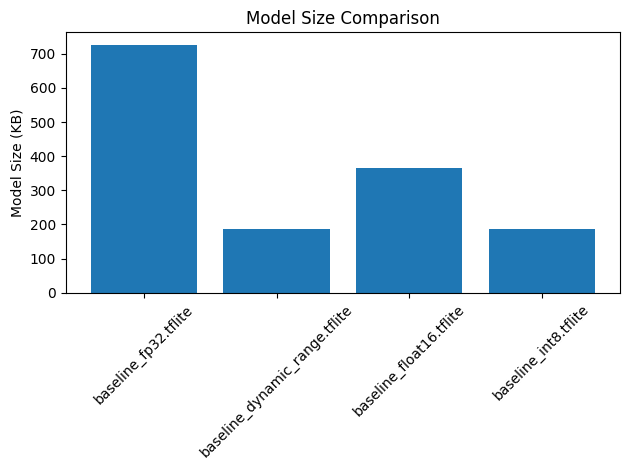

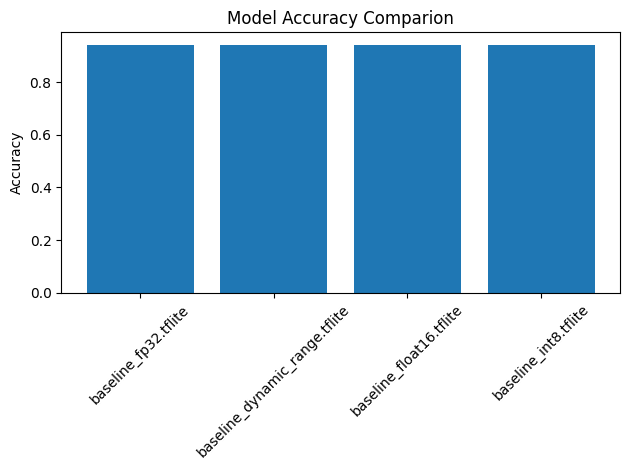

In [110]:
# TODO:
# Create one bar plot for model size and another for test accuracy.

# <-- Enter your code here <--#
plt.figure()
plt.bar(comparison_df["file"], comparison_df["size_kb"])
plt.ylabel("Model Size (KB)")
plt.title("Model Size Comparison")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()


plt.figure()
plt.bar(comparison_df["file"], comparison_df["accuracy"])
plt.title("Model Accuracy Comparion")
plt.ylabel("Accuracy")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

### Confusion Matrix for the PTQ Int8 Model


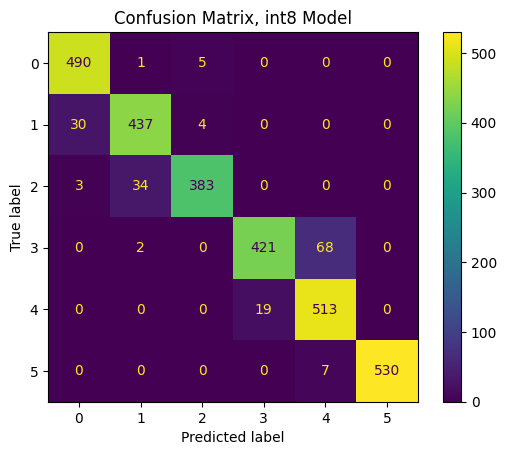

Classification Report Int8 Model
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       496
           1       0.92      0.93      0.92       471
           2       0.98      0.91      0.94       420
           3       0.96      0.86      0.90       491
           4       0.87      0.96      0.92       532
           5       1.00      0.99      0.99       537

    accuracy                           0.94      2947
   macro avg       0.94      0.94      0.94      2947
weighted avg       0.94      0.94      0.94      2947



In [88]:
# TODO:
# Plot the confusion matrix for the PTQ int8 model.
# Print the classification report for the PTQ int8 model.

# <-- Enter your code here <--#
confuse = confusion_matrix(y_test, int8_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = confuse)
disp.plot()
plt.title("Confusion Matrix, int8 Model")
plt.show()


print("Classification Report Int8 Model")
print(classification_report(y_test, int8_pred))

## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [91]:
# TODO:
# Create a QAT model from the trained baseline model using TF-MOT.
# Compile it with Adam(1e-4), sparse_categorical_crossentropy, and accuracy.

# <-- Enter your code here <--#
qat_model= tfmot.quantization.keras.quantize_model(baseline_model)

qat_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-4),
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"],
)
qat_model.summary()


Model: "baseline_dnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 features (InputLayer)       [(None, 561)]             0         
                                                                 
 quantize_layer_1 (Quantize  (None, 561)               3         
 Layer)                                                          
                                                                 
 quant_dense_7 (QuantizeWra  (None, 256)               143877    
 pperV2)                                                         
                                                                 
 quant_dense_8 (QuantizeWra  (None, 128)               32901     
 pperV2)                                                         
                                                                 
 quant_dense_9 (QuantizeWra  (None, 64)                8261      
 pperV2)                                              

### Fine-Tune the QAT Model


In [95]:
# TODO:
# Fine-tune the QAT model for 8 epochs using validation_split=0.2 and batch_size=64.

# <-- Enter your code here <--#
history_qat = qat_model.fit (
    X_train,
    y_train, 
    validation_split = .2,
    epochs = 8,
    batch_size = 64,
    verbose =1,
)



Epoch 1/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0352 - accuracy: 0.9912 - val_loss: 0.1198 - val_accuracy: 0.9572
Epoch 2/8
92/92 [==============================] - 0s 1ms/step - loss: 0.0283 - accuracy: 0.9906 - val_loss: 0.1211 - val_accuracy: 0.9585
Epoch 3/8
92/92 [==============================] - 0s 1ms/step - loss: 0.0283 - accuracy: 0.9912 - val_loss: 0.1214 - val_accuracy: 0.9579
Epoch 4/8
92/92 [==============================] - 0s 1ms/step - loss: 0.0247 - accuracy: 0.9917 - val_loss: 0.1215 - val_accuracy: 0.9579
Epoch 5/8
92/92 [==============================] - 0s 1ms/step - loss: 0.0238 - accuracy: 0.9915 - val_loss: 0.1468 - val_accuracy: 0.9572
Epoch 6/8
92/92 [==============================] - 0s 1ms/step - loss: 0.0257 - accuracy: 0.9898 - val_loss: 0.1355 - val_accuracy: 0.9585
Epoch 7/8
92/92 [==============================] - 0s 1ms/step - loss: 0.0235 - accuracy: 0.9918 - val_loss: 0.1305 - val_accuracy: 0.9606
Epoch 8/8
92/92 [==========

### Evaluate the QAT Keras Model


In [96]:
# TODO:
# Evaluate the QAT Keras model on X_test.
# Print the test accuracy and classification report.

# <-- Enter your code here <--#
qat_loss, qat_accuracy = qat_model.evaluate(X_test, y_test, verbose =0)
y_pred_qat = np.argmax(qat_model.predict(X_test), axis = 1)
print(f"QAT test accuracy: {qat_accuracy:.4f}")
print(classification_report(y_test, y_pred_qat))



93/93 [==============================] - 0s 434us/step
QAT test accuracy: 0.9477
              precision    recall  f1-score   support

           0       0.93      0.98      0.95       496
           1       0.94      0.92      0.93       471
           2       0.97      0.95      0.96       420
           3       0.96      0.87      0.91       491
           4       0.89      0.97      0.93       532
           5       1.00      1.00      1.00       537

    accuracy                           0.95      2947
   macro avg       0.95      0.95      0.95      2947
weighted avg       0.95      0.95      0.95      2947



### Convert the QAT Model to Int8 TensorFlow Lite


In [98]:
# TODO:
# Convert the QAT model to int8 TensorFlow Lite.
# Save the model, compute its size, and evaluate it on the test set.

# <-- Enter your code here <--#
qat_int8_tflite = convert_to_tflite_int8(qat_model)
qat_int8_size = save_binary_model(qat_int8_tflite, "qat_model_integer_quant.tflite")
qat_int8_acc, qat_int8_preds = evaluate_tflite_model(qat_int8_tflite, X_test, y_test)

print(f"QAT int8 size: {qat_int8_size: .2f} KB")
print(f"QAT int8 accuracy: {qat_int8_acc: .4f}")




INFO:tensorflow:Assets written to: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmpl9usn_8h/assets


INFO:tensorflow:Assets written to: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmpl9usn_8h/assets
/Users/praxideswanyoike/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-20 19:49:50.714898: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-20 19:49:50.714911: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.


QAT int8 size:  185.78 KB
QAT int8 accuracy:  0.9477


2026-04-20 19:49:50.714981: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmpl9usn_8h
2026-04-20 19:49:50.715716: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-20 19:49:50.715719: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmpl9usn_8h
2026-04-20 19:49:50.717968: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-20 19:49:50.741820: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmpl9usn_8h
2026-04-20 19:49:50.748555: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 33574 microseconds.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


## 12. PTQ Int8 vs QAT Int8


In [103]:
# TODO:
# Create a DataFrame comparing PTQ int8 and QAT int8:
# Model, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#
qat_ptq_df = pd.DataFrame ([
    {
        "Model" : "PTQ int8", 
        "Test Accuracy": round(float(int8_acc), 4),
        "Model Size (KB)" : round(float(int8_size), 2), 
    }, 
    { 
        "Model Qat": "QAT int8",
        "Test Accuracy": round(float(qat_int8_acc), 4),
        "Model Size (KB)": round(float(qat_int8_size), 2),
    },
])

qat_ptq_df
    

,Model,Test Accuracy,Model Size (KB),Model Qat
0,PTQ int8,0.9413,185.38,NaN
1,NaN,0.9477,185.78,QAT int8


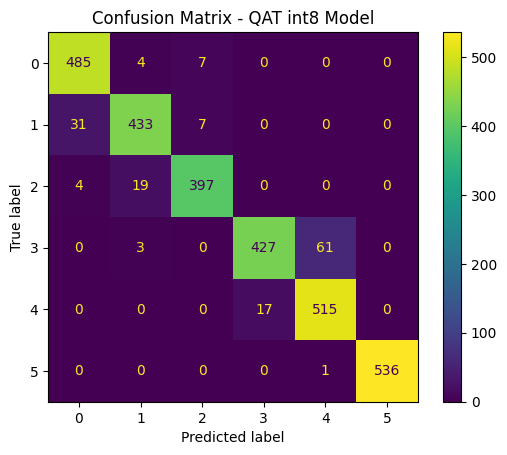

In [106]:
# TODO:
# Plot the confusion matrix for the QAT int8 model.

# <-- Enter your code here <--#
cm_qat = confusion_matrix(y_test, qat_int8_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_qat)
disp.plot()
plt.title("Confusion Matrix - QAT int8 Model")
plt.show()


## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size?
2. Which quantization method gave the best accuracy among the TensorFlow Lite models?
3. Did QAT improve the final int8 model compared with PTQ int8?
4. Why is this dataset a good fit for a DNN-based TinyML workflow?
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?

In [ ]:
1. Dynamic range and Int 8 methods gave the smallest model size.
2. The accuracies across all my methods where quite similar and perfomed around the same at over 90%.
3. Yes, the QAT improved the final int8 cmodel compared to the PTQ int8.
4. This is a good fit because it is structured with fixed input size.
5.  I would choose the QAT int8 model because it has high accuracy and maintains a small footprint. 



## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
